<a href="https://colab.research.google.com/github/hareezzvijey/Amrita_AI_Research_Internship/blob/main/Day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sequence Learning Models: RNN → LSTM → GRU → Attention (Transformers)

This notebook demonstrates the evolution of sequence learning models in deep learning, starting from basic Recurrent Neural Networks (RNNs) to advanced attention-based architectures (Transformers).

## Objective:

* To understand how sequential data is processed using RNNs.
* To analyze the limitations of RNNs, particularly the vanishing and exploding gradient problems.
* To explore how LSTM and GRU architectures overcome these limitations using gating mechanisms.
* To introduce self-attention mechanisms and understand how Transformers eliminate recurrence while effectively capturing dependencies in sequences.

## Workflow:

1. Implement a basic RNN model and observe its behavior on sequential data.
2. Demonstrate the vanishing/exploding gradient problem by increasing sequence length.
3. Implement LSTM and GRU models and compare their performance with RNN.
4. Explore attention mechanisms and understand how dependencies are captured without recurrence.
5. Compare all models based on performance, stability, and scalability.

## Key Concepts Covered:

* Sequential data processing
* Hidden states and temporal dependencies
* Backpropagation Through Time (BPTT)
* Vanishing & Exploding Gradients
* Gating mechanisms (LSTM & GRU)
* Self-Attention and Transformers

## Outcome:

By the end of this notebook, we gain a clear understanding of how sequence models evolved and why modern architectures like Transformers are preferred for handling long-range dependencies in real-world applications.


## RNN Implementation and its issues

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Sample Dataset
sentences = [
    "I love this movie",
    "This film is amazing",
    "I hate this movie",
    "This film is terrible",
    "I really like this",
    "I dislike this a lot"
]

labels = [1, 1, 0, 0, 1, 0]  # 1 = positive, 0 = negative

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

# Pad sequences to same length
X = pad_sequences(sequences, maxlen=5)
y = np.array(labels)

print("Word Index:", tokenizer.word_index)
print("Sequences:", X)

Word Index: {'this': 1, 'i': 2, 'movie': 3, 'film': 4, 'is': 5, 'love': 6, 'amazing': 7, 'hate': 8, 'terrible': 9, 'really': 10, 'like': 11, 'dislike': 12, 'a': 13, 'lot': 14}
Sequences: [[ 0  2  6  1  3]
 [ 0  1  4  5  7]
 [ 0  2  8  1  3]
 [ 0  1  4  5  9]
 [ 0  2 10 11  1]
 [ 2 12  1 13 14]]


In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

15


### Build RNN

🔹 Embedding Layer Explanation

 output_dim = 8 means:

Each word is converted into a vector of 8 numbers

 Example:

"love" → [0.2, -0.1, 0.7, 0.5, -0.3, 0.9, 0.1, -0.4]

These 8 numbers represent features of the word.

The model learns these features automatically during training.

You can think of them as capturing properties like:

 - emotion
 - meaning
 - context

 More dimensions → richer representation of the word

In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=8, input_length=5),  # word → vector
    SimpleRNN(16, activation='tanh'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Input size = 5 - no.of reccurence = 5

16 is no.of hidden units - how much information per step

- Time step 1 → h1 = [16 values]
- Time step 2 → h2 = [16 values]
- Time step 3 → h3 = [16 values]
- Time step 4 → h4 = [16 values]
- Time step 5 → h5 = [16 values]

So increasing the input length drastically cause the gradient issues

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 0.7042
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3333 - loss: 0.7006
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.6970
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.6935
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6900
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.6865
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.6830
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5000 - loss: 0.6795
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 0.6760
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6667 - loss: 0.6724
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6667 - loss: 0.6689
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6667 - loss: 0.6653
Epo

In [ ]:
test_sentence = ["I love this film"]

test_seq = tokenizer.texts_to_sequences(test_sentence)
test_pad = pad_sequences(test_seq, maxlen=5)

prediction = model.predict(test_pad)

print("Prediction:", prediction[0][0])
if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: 0.53162324
Positive


Using complex sentences

In [ ]:
test_sentence = ["I do not like this movie but it was good for one time watch"] # Negative sentence
test_seq = tokenizer.texts_to_sequences(test_sentence)
test_pad = pad_sequences(test_seq, maxlen=5)

prediction = model.predict(test_pad)

print("Prediction:", prediction[0][0])
if prediction[0][0] > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: 0.5288304
Positive


## vanishing/exploding gradient problem

In [ ]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(path + "/IMDB Dataset.csv")

print(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Use subset
df = df.sample(10000)

sentences = df['review'].values
labels = df['sentiment'].values

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

X = pad_sequences(sequences, maxlen=160)
y = np.array(labels)

print(X)
print(y)

[[  71    1 4424 ...    1 7534  700]
 [   0    0    0 ...    8    1  194]
 [   0    0    0 ...  854   10  615]
 ...
 [   0    0    0 ...   47    3  450]
 [ 192  447    9 ...    5   76   11]
 [  24 1113 2712 ...  123    1 1436]]
[0 0 0 ... 0 1 0]


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=100), # Increased the input length
    tf.keras.layers.SimpleRNN(64), # increased the hidden units
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.BinaryCrossentropy()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Loop to capture the gradient

In [ ]:
gradient_norms = []

for epoch in range(10):
    with tf.GradientTape() as tape:
        predictions = model(X[:2000], training=True)
        loss = loss_fn(y[:2000], predictions)

    grads = tape.gradient(loss, model.trainable_variables)

    # Compute gradient norm
    total_norm = 0
    for g in grads:
        if g is not None:
            total_norm += tf.reduce_sum(tf.square(g))

    total_norm = tf.sqrt(total_norm)
    gradient_norms.append(total_norm.numpy())

    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    print(f"Epoch {epoch}, Loss: {loss.numpy():.4f}, Grad Norm: {total_norm.numpy():.4f}")

Epoch 0, Loss: 0.6976, Grad Norm: 0.1669
Epoch 1, Loss: 0.6765, Grad Norm: 0.1542
Epoch 2, Loss: 0.6561, Grad Norm: 0.2177
Epoch 3, Loss: 0.6307, Grad Norm: 0.3689
Epoch 4, Loss: 0.6031, Grad Norm: 0.9922
Epoch 5, Loss: 0.5718, Grad Norm: 0.9959
Epoch 6, Loss: 0.5404, Grad Norm: 1.8282
Epoch 7, Loss: 0.4938, Grad Norm: 1.2752
Epoch 8, Loss: 0.4631, Grad Norm: 3.0218
Epoch 9, Loss: 0.4362, Grad Norm: 6.5695


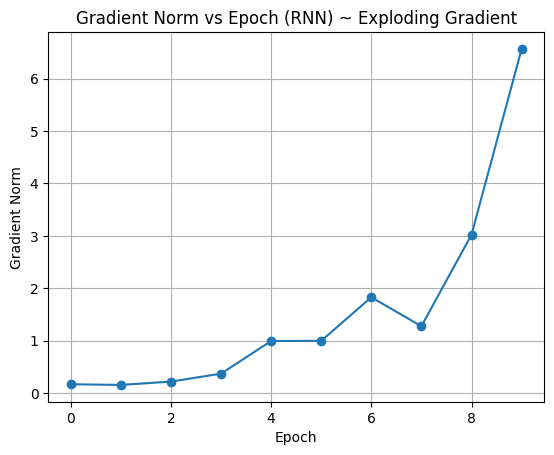

In [ ]:
import matplotlib.pyplot as plt

plt.plot(gradient_norms, marker='o')
plt.title("Gradient Norm vs Epoch (RNN) ~ Exploding Gradient")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.grid()
plt.show()

Causes:
- Large dataset (IMDB)
- Long sequence (160 tokens)
- ​∂L / ∂h0 ​∝ (Whh​)t

## Implement LSTM and GRU models and compare their performance with RNN.

In [ ]:
def build_rnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=100),
        tf.keras.layers.SimpleRNN(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_lstm():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=100),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_gru():
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=10000, output_dim=32, input_length=100),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
def train_model(model, X, y, name):
    optimizer = tf.keras.optimizers.Adam()
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    grad_norms = []
    losses = []

    for epoch in range(10):
        with tf.GradientTape() as tape:
            preds = model(X[:2000], training=True)
            loss = loss_fn(y[:2000], preds)

        grads = tape.gradient(loss, model.trainable_variables)

        total_norm = 0
        for g in grads:
            if g is not None:
                total_norm += tf.reduce_sum(tf.square(g))

        total_norm = tf.sqrt(total_norm)

        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        grad_norms.append(total_norm.numpy())
        losses.append(loss.numpy())

        print(f"{name} Epoch {epoch} | Loss: {loss.numpy():.4f} | Grad: {total_norm.numpy():.4f}")

    return losses, grad_norms

In [ ]:
rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()

rnn_loss, rnn_grad = train_model(rnn_model, X, y, "RNN")
lstm_loss, lstm_grad = train_model(lstm_model, X, y, "LSTM")
gru_loss, gru_grad = train_model(gru_model, X, y, "GRU")

RNN Epoch 0 | Loss: 0.7004 | Grad: 0.1872
RNN Epoch 1 | Loss: 0.6768 | Grad: 0.1753
RNN Epoch 2 | Loss: 0.6519 | Grad: 0.2769
RNN Epoch 3 | Loss: 0.6222 | Grad: 0.6793
RNN Epoch 4 | Loss: 0.5881 | Grad: 0.8388
RNN Epoch 5 | Loss: 0.5523 | Grad: 1.3952
RNN Epoch 6 | Loss: 0.5161 | Grad: 1.8307
RNN Epoch 7 | Loss: 0.4777 | Grad: 2.9820
RNN Epoch 8 | Loss: 0.4402 | Grad: 4.5634
RNN Epoch 9 | Loss: 0.4069 | Grad: 8.0609
LSTM Epoch 0 | Loss: 0.6933 | Grad: 0.0085
LSTM Epoch 1 | Loss: 0.6925 | Grad: 0.0057
LSTM Epoch 2 | Loss: 0.6917 | Grad: 0.0073


ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 488, in while_loop
    loop_vars = body(*loop_vars)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 479, in <lambda>
    body = lambda i, lv: (i + 1, orig_body(*lv))  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 426, in _step
    return (time + 1, output_ta_t) + tuple(new_states)  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/rnn.py", line 420, in <genexpr>
    for ta, out in zip(output_ta_t, flat_output)  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(

LSTM Epoch 3 | Loss: 0.6907 | Grad: 0.0095
LSTM Epoch 4 | Loss: 0.6895 | Grad: 0.0112
LSTM Epoch 5 | Loss: 0.6881 | Grad: 0.0130
LSTM Epoch 6 | Loss: 0.6865 | Grad: 0.0154
LSTM Epoch 7 | Loss: 0.6845 | Grad: 0.0187
LSTM Epoch 8 | Loss: 0.6821 | Grad: 0.0230
LSTM Epoch 9 | Loss: 0.6793 | Grad: 0.0281
GRU Epoch 0 | Loss: 0.6935 | Grad: 0.0115
GRU Epoch 1 | Loss: 0.6923 | Grad: 0.0077
GRU Epoch 2 | Loss: 0.6911 | Grad: 0.0109
GRU Epoch 3 | Loss: 0.6898 | Grad: 0.0128
GRU Epoch 4 | Loss: 0.6882 | Grad: 0.0141
GRU Epoch 5 | Loss: 0.6863 | Grad: 0.0162
GRU Epoch 6 | Loss: 0.6842 | Grad: 0.0194
GRU Epoch 7 | Loss: 0.6818 | Grad: 0.0230
GRU Epoch 8 | Loss: 0.6790 | Grad: 0.0266
GRU Epoch 9 | Loss: 0.6758 | Grad: 0.0302


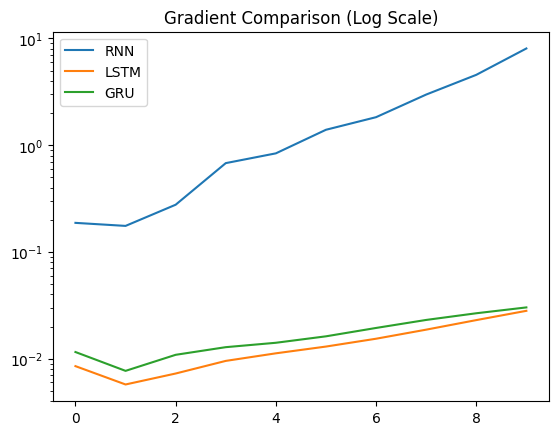

In [ ]:
plt.plot(rnn_grad, label="RNN")
plt.plot(lstm_grad, label="LSTM")
plt.plot(gru_grad, label="GRU")

plt.yscale('log')

plt.legend()
plt.title("Gradient Comparison (Log Scale)")
plt.show()

## Explore attention mechanisms and understand how dependencies are captured without recurrence.

In [ ]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(path + "/IMDB Dataset.csv")

print(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Use subset
df = df.sample(10000)

sentences = df['review'].values
labels = df['sentiment'].values

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

X = pad_sequences(sequences, maxlen=160)
y = np.array(labels)

print(X)
print(y)

[[   0    0    0 ...    5  326   98]
 [ 303 5979    1 ...    3 3932  290]
 [ 107   80 1257 ... 6530   20    9]
 ...
 [  72  416    5 ... 1729   11  714]
 [4361    1   19 ... 5966   22 2550]
 [  65  399  157 ...   36 1198  203]]
[0 1 1 ... 0 1 1]


Transformer Block

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()
        self.dropout1 = layers.Dropout(0.1)
        self.dropout2 = layers.Dropout(0.1)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

Positional Encoding

In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

Build Transformer Model

In [ ]:
maxlen = 160
vocab_size = 10000
embed_dim = 32
num_heads = 2
ff_dim = 32

inputs = layers.Input(shape=(maxlen,))

embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)

transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x, training=True) # Pass the 'training' argument

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

Compile and run

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.fit(X[:10000], y[:10000], epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - accuracy: 0.6672 - loss: 0.5717 - val_accuracy: 0.8260 - val_loss: 0.3973
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8906 - loss: 0.2746 - val_accuracy: 0.8610 - val_loss: 0.3272
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.9440 - loss: 0.1540 - val_accuracy: 0.8560 - val_loss: 0.3995
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9732 - loss: 0.0866 - val_accuracy: 0.8490 - val_loss: 0.5687
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.9843 - loss: 0.0496 - val_accuracy: 0.8460 - val_loss: 0.6730


Note:
But validation is getting worse

Look carefully:

Val Loss: 0.32 → 0.39 → 0.56 → 0.67 (Increases)

Val Acc:  86% → 85% → 84% (Decreases)

- This is OVERFITTING

Reason:

The Transformer model achieves peak validation performance at early epochs (epoch 2), after which validation accuracy declines while training accuracy continues to improve. This indicates early overfitting, demonstrating that attention-based models, while powerful, require careful regularization and training control.

### Optimizing the transfomer model to prevent overfit

- either add the early stopping method

- Change the parameters accordingly

In [ ]:
import kagglehub
import pandas as pd
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
df = pd.read_csv(path + "/IMDB Dataset.csv")

print(df.head())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Use subset
df = df.sample(10000)

sentences = df['review'].values
labels = df['sentiment'].values

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(sentences)

sequences = tokenizer.texts_to_sequences(sentences)

X = pad_sequences(sequences, maxlen=160)
y = np.array(labels)

print(X)
print(y)

[[   0    0    0 ...    7    7 7448]
 [   1   19    1 ...  512  354    9]
 [  73   24   21 ...  154    5  105]
 ...
 [   0    0    0 ...   11 1052 4861]
 [   0    0    0 ... 5171 4401    8]
 [   8   56   22 ...   25   12  874]]
[1 1 0 ... 0 0 0]


In [ ]:
maxlen = 160
vocab_size = 10000
embed_dim = 16
num_heads = 2
ff_dim = 16

inputs = layers.Input(shape=(maxlen,))

embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)

transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)
x = transformer_block(x, training=True)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(20, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

model.fit(X[:10000], y[:10000],
          epochs=10,
          validation_split=0.2,
          callbacks=[early_stop]
          )

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.5922 - loss: 0.6553 - val_accuracy: 0.8290 - val_loss: 0.4707
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8500 - loss: 0.3734 - val_accuracy: 0.8600 - val_loss: 0.3323
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.9273 - loss: 0.2111 - val_accuracy: 0.8550 - val_loss: 0.3697


## Convolutional Neural Network

In [7]:
import tensorflow as tf
import numpy as np

# Load the MNIST dataset directly from Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the images
# Normalize images to the range [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to (height, width, channels) for CNNs
x_train = np.expand_dims(x_train, -1) # Add channel dimension
x_test = np.expand_dims(x_test, -1)

# Create TensorFlow datasets
BUFFER_SIZE = 1024
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)

print("Train dataset example shape:", x_train.shape)
print("Validation dataset example shape:", x_test.shape)
print("Number of training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Number of validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train dataset example shape: (60000, 28, 28, 1)
Validation dataset example shape: (10000, 28, 28, 1)
Number of training batches: 1875
Number of validation batches: 313


In [6]:
import os

print("Contents of the downloaded dataset path:")
for item in os.listdir(path):
    print(os.path.join(path, item))

Contents of the downloaded dataset path:
/root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1/t10k-images.idx3-ubyte
/root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1/train-labels.idx1-ubyte
/root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1/t10k-labels.idx1-ubyte
/root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1/train-images.idx3-ubyte


In [8]:
import numpy as np
import struct

# Load images
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

# Load labels
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

Load the dataset

In [9]:
base_path = "/root/.cache/kagglehub/datasets/mannu1170/minst-dataset/versions/1/"

X_train = load_images(base_path + "train-images.idx3-ubyte")
y_train = load_labels(base_path + "train-labels.idx1-ubyte")

X_test = load_images(base_path + "t10k-images.idx3-ubyte")
y_test = load_labels(base_path + "t10k-labels.idx1-ubyte")

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


60000/10000 images

Each image = 28 × 28 pixels

Preprocess the data

In [11]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension (VERY IMPORTANT for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1) # shape becomes(60000, 28, 28, 1)

Build CNN

Input - (images, height, width, grayscale(1)/RGB(3))

In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.7522 - loss: 0.7031 - val_accuracy: 0.9446 - val_loss: 0.1782
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9530 - loss: 0.1483 - val_accuracy: 0.9641 - val_loss: 0.1204
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9678 - loss: 0.1020 - val_accuracy: 0.9757 - val_loss: 0.0804
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - accuracy: 0.9740 - loss: 0.0838 - val_accuracy: 0.9755 - val_loss: 0.0773
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9782 - loss: 0.0697 - val_accuracy: 0.9784 - val_loss: 0.0626


Model evaluvation and prediction

In [16]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9784 - loss: 0.0626


[0.06264618784189224, 0.9783999919891357]

In [17]:
import numpy as np

pred = model.predict(X_test[:1])
print("Predicted:", np.argmax(pred))
print("Actual:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Predicted: 7
Actual: 7


Visualize the accuracy and loss

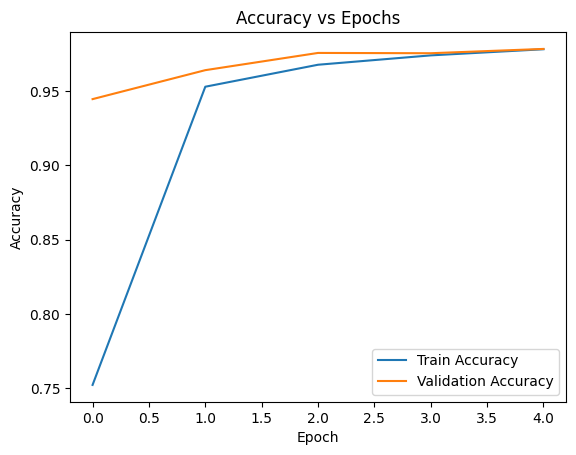

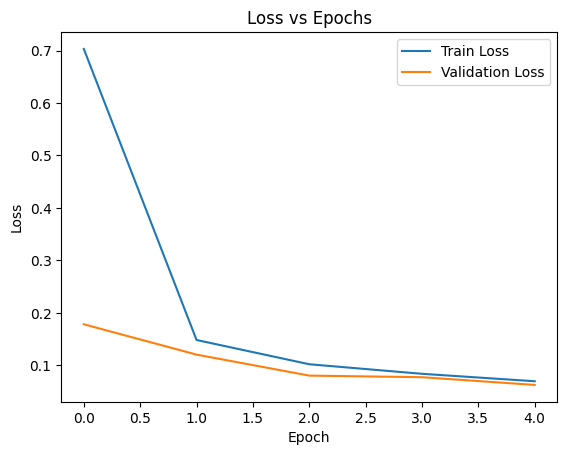

In [18]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()